In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\baw61\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

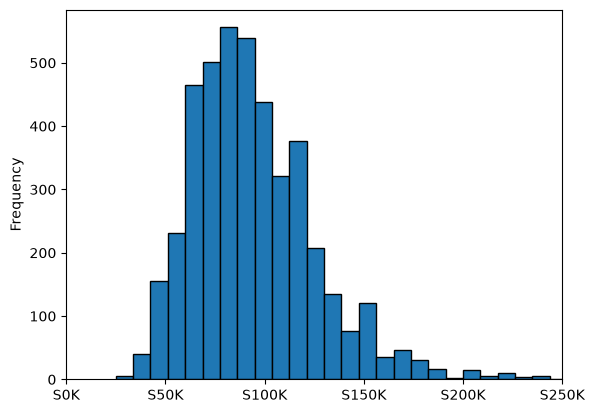

In [11]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')
plt.xlim(0, 250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'S{int(x/1000)}K'))

In [12]:
df_DS = df[df['job_title_short'] == 'Data Scientist']

<Axes: ylabel='Frequency'>

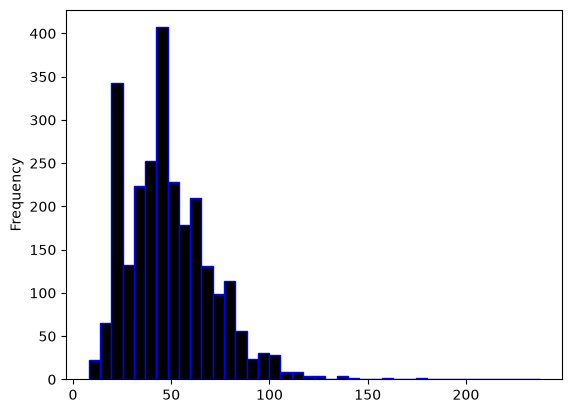

In [16]:
df_DS['salary_hour_avg'].plot(kind='hist', bins=40, edgecolor='blue', color='black')

In [29]:
df_skills = df.dropna(subset=['job_skills']).copy()
df_skills['num_skills'] = df_skills['job_skills'].apply(len)

<Axes: ylabel='Frequency'>

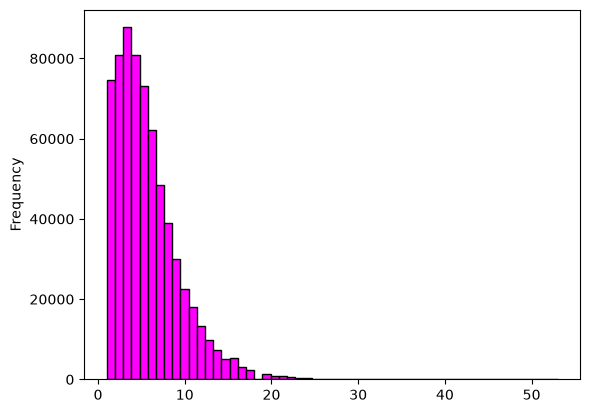

In [31]:
df_skills['num_skills'].plot(kind='hist', bins=55, color='magenta', edgecolor='black')

In [27]:
df.shape

(785741, 17)

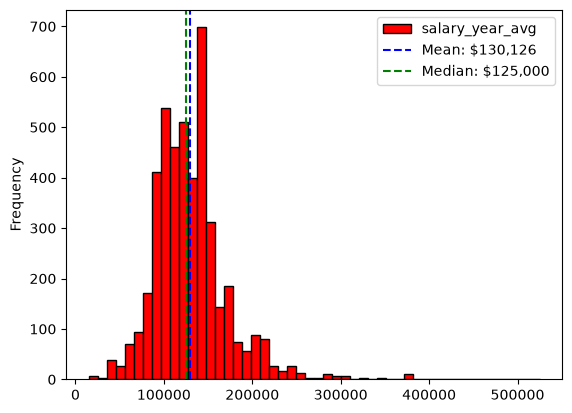

In [42]:
df_DE = df[df['job_title_short'] == 'Data Engineer']
df_DE = df_DE.dropna(subset=['salary_year_avg'])
mean_salary = df_DE['salary_year_avg'].mean()
median_salary = df_DE['salary_year_avg'].median()
df_DE['salary_year_avg'].plot(kind='hist', bins=50, color='red', edgecolor='black')
plt.axvline(mean_salary, color='blue', linestyle='dashed', label = f'Mean: ${mean_salary:,.0f}')
plt.axvline(median_salary, color='green', linestyle='dashed', label = f'Median: ${median_salary:,.0f}')
plt.legend()
plt.show()